# Halo Mass Function vs Observational Data

In [1]:
import os, sys
import matplotlib.pylab as plt
from matplotlib import rc, rcParams
from matplotlib import cm, colors
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import LogFormatter
from cycler import cycler
from astropy.io import fits
from scipy.optimize import curve_fit
from scipy import stats 
from scipy import interpolate

# from uncertainties import unumpy, ufloat

default_cycler = (cycler(color=['r', 'g', 'b', 'y']) +
                  cycler(linestyle=['-', '--', ':', '-.']))
plt.rc('lines', linewidth=2.5)
plt.rc('axes', prop_cycle=default_cycler)
rcParams['agg.path.chunksize'] = 10000

#rc("font", weight="bold"); rc("font", size="13")
rc("axes"); rc("axes",labelsize="16"); rc("xtick",labelsize="16"); rc("ytick",labelsize="16")#, labelweight="bold"
plt.rcParams['text.usetex']=True
#plt.rcParams[r"text.latex.preamble"] = [r"\usepackage{amsmath}"]
font = {'family': 'monospace',
        'color':  'black',
        'weight': 'normal',
        'size': 16,
        'style':'roman',
        }

In [2]:
import numpy as np
from astropy.io import fits, ascii
from astropy.cosmology import FlatLambdaCDM

from hmf import GrowthFactor
from hmf.cosmology import cosmo
from hmf import MassFunction 
from hmf.mass_function import FittingFunction
from hmf.halos import MassDefinition

import camb

## [Cosmological Varaibles]

In [3]:
# Planck2020 parameters:
h=h0=0.6732
om0=0.3158
ob0h2=0.022383
ob0=ob0h2/h**2
ns=0.96605
sig8=0.8120
t_cmb=2.7255
fbary=ob0h2/h**2/om0

# set up cosmological model:
planck2020_model=FlatLambdaCDM(H0 = 100*h, Om0=om0, Tcmb0 = t_cmb, Ob0 = ob0)

## HMF

In [4]:
FiTFunc, FTK = 'Sheth-Mo-Tormen', 'SMT'
min_mval_log10=7
mf = MassFunction(Mmin=min_mval_log10, Mmax=13, z = 0.0, growth_model='CambGrowth', sigma_8 = sig8, n = ns, \
                         transfer_model='CAMB', hmf_model=FTK, \
                         mdef_model = None, disable_mass_conversion=True, filter_model = 'TopHat', transfer_params={'extrapolate_with_eh':True})

In [5]:
mf.rho_gtm

array([5.21468079e+10, 5.21204010e+10, 5.20939396e+10, 5.20674243e+10,
       5.20408555e+10, 5.20142333e+10, 5.19875576e+10, 5.19608279e+10,
       5.19340441e+10, 5.19072062e+10, 5.18803139e+10, 5.18533670e+10,
       5.18263647e+10, 5.17993063e+10, 5.17721913e+10, 5.17450197e+10,
       5.17177920e+10, 5.16905086e+10, 5.16631698e+10, 5.16357753e+10,
       5.16083247e+10, 5.15808178e+10, 5.15532546e+10, 5.15256350e+10,
       5.14979584e+10, 5.14702243e+10, 5.14424319e+10, 5.14145806e+10,
       5.13866705e+10, 5.13587020e+10, 5.13306756e+10, 5.13025915e+10,
       5.12744495e+10, 5.12462491e+10, 5.12179902e+10, 5.11896727e+10,
       5.11612965e+10, 5.11328611e+10, 5.11043659e+10, 5.10758100e+10,
       5.10471929e+10, 5.10185145e+10, 5.09897754e+10, 5.09609760e+10,
       5.09321166e+10, 5.09031969e+10, 5.08742165e+10, 5.08451752e+10,
       5.08160729e+10, 5.07869095e+10, 5.07576846e+10, 5.07283973e+10,
       5.06990471e+10, 5.06696330e+10, 5.06401553e+10, 5.06106142e+10,
      

## [Uncover Data]

In [6]:
# DR4
#Photometric redshift
#HUData_phot = fits.open('./ObsData/UNCOVER/UNCOVER_DR2.1_SPS_catalog.fits.gz')
HUData_phot = fits.open('../data/UNCOVER_DR4_SPS_catalog.fits')
#Spectroscopic redshift
HUData = fits.open('../data/UNCOVER_DR4_SPS_zspec_catalog.fits')
#HUData = ascii.read('./ObsData/UNCOVER/spscat.dat.gz')

In [7]:
hg_mass_mask = (~np.isnan(HUData_phot[1].data['z_16'])) & (~np.isnan(HUData_phot[1].data['z_84'])) #& \
#                ((HUData_phot[1].data['z_50'] - HUData_phot[1].data['z_16']) <= 1.) & \
#                ((HUData_phot[1].data['z_84'] - HUData_phot[1].data['z_50']) <= 1.)       

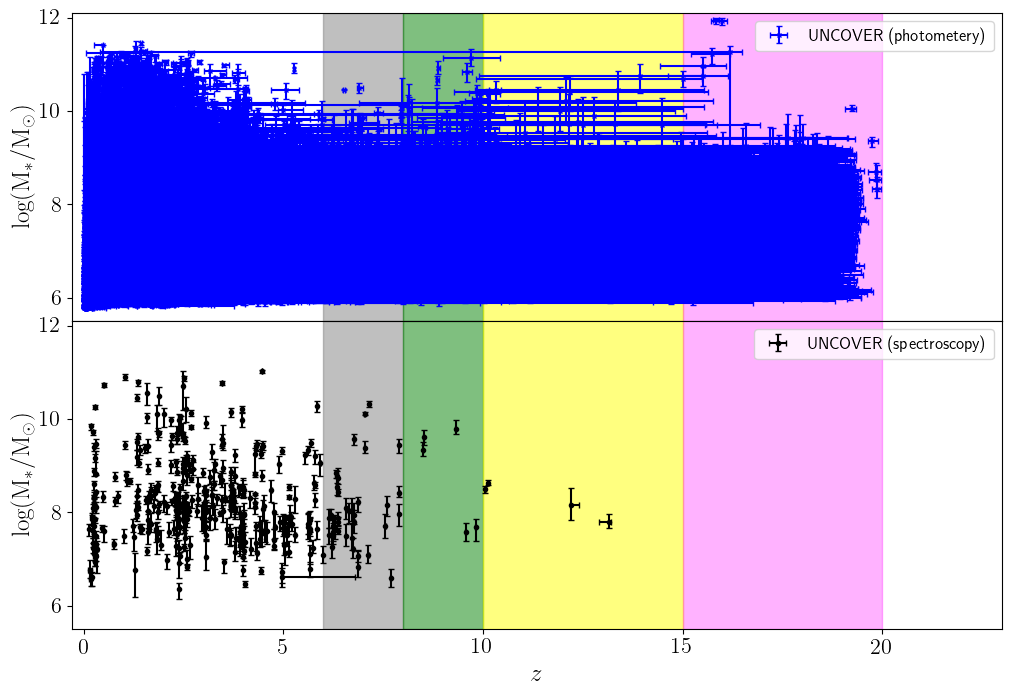

In [8]:
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(12,8), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.0, hspace=0.0)
ax1.errorbar(HUData_phot[1].data['z_50'][hg_mass_mask], HUData_phot[1].data['mstar_50'][hg_mass_mask], fmt='x', \
             xerr=[HUData_phot[1].data['z_50'][hg_mass_mask] - HUData_phot[1].data['z_16'][hg_mass_mask], HUData_phot[1].data['z_84'][hg_mass_mask] - HUData_phot[1].data['z_50'][hg_mass_mask]],
             yerr=[HUData_phot[1].data['mstar_50'][hg_mass_mask] - HUData_phot[1].data['mstar_16'][hg_mass_mask], HUData_phot[1].data['mstar_84'][hg_mass_mask] - HUData_phot[1].data['mstar_50'][hg_mass_mask]],\
            capsize=2, elinewidth=1.5, c='b', ms=3, label=r'UNCOVER (photometery)')

ax2.errorbar(HUData[1].data['z_spec50'], HUData[1].data['mstar_50'], fmt='.', \
             xerr=[HUData[1].data['z_spec50'] - HUData[1].data['z_spec16'], HUData[1].data['z_spec84'] - HUData[1].data['z_spec50']],
             yerr=[HUData[1].data['mstar_50'] - HUData[1].data['mstar_16'], HUData[1].data['mstar_84'] - HUData[1].data['mstar_50']],\
            capsize=2, elinewidth=1.5, c='k', label=r'UNCOVER (spectroscopy)')

#labbe 2023
# ax1.errorbar(labbe_dat['z'], labbe_dat['mass'], xerr=[labbe_dat['z']-labbe_dat['zlo'], labbe_dat['zhi']-labbe_dat['z']], \
#                                                 yerr=[labbe_dat['mass']-labbe_dat['masslo'], labbe_dat['masshi']-labbe_dat['mass']],\
#                                                 fmt='x', capsize=3, elinewidth=1.5, color='r', ms=5, label=r'Labbe at al 23')
# ax2.errorbar(labbe_dat['z'], labbe_dat['mass'], xerr=[labbe_dat['z']-labbe_dat['zlo'], labbe_dat['zhi']-labbe_dat['z']], \
#                                                 yerr=[labbe_dat['mass']-labbe_dat['masslo'], labbe_dat['masshi']-labbe_dat['mass']],\
#                                                 fmt='x', capsize=3, elinewidth=1.5, color='r', ms=5)
ax1.axvspan(6,8, color='gray', alpha=0.5)
ax1.axvspan(8,10, color='green', alpha=0.5)
ax1.axvspan(10,15, color='yellow', alpha=0.5)
ax1.axvspan(15,20, color='magenta', alpha=0.3)

ax2.axvspan(6,8, color='gray', alpha=0.5)
ax2.axvspan(8,10, color='green', alpha=0.5)
ax2.axvspan(10,15, color='yellow', alpha=0.5)
ax2.axvspan(15,20, color='magenta', alpha=0.3)


ax1.legend(fontsize=12, loc='upper right')
ax2.legend(fontsize=12, loc='upper right')

ax1.set_xlim(-0.3, 23)
ax1.set_ylim(5.5, 12.1)
ax2.set_xlabel(r'$z$', fontsize=18)
ax1.set_ylabel(r'$\rm log (M_*/M_{\odot})$', fontsize=18)
ax2.set_ylabel(r'$\rm log (M_*/M_{\odot})$', fontsize=18)
#plt.savefig(savedir + 'StellarMass_UNCOVER.png', bbox_inches='tight')
plt.show()

### [Volume Fraction]

In [9]:
# 4 pi steradians converted to arcmin^2:
arcmin2_fullsky=(180/np.pi)**2*4*np.pi*60**2
# uncover area:
uncover_arcmin2=45.0
# volume fraction is ceers area divided full sky volume
vol_frac=uncover_arcmin2/arcmin2_fullsky

In [10]:
zbin_lo, zbin_hi = 6.0, 8.0
#zbin_lo, zbin_hi = 8.0, 10.0
#zbin_lo, zbin_hi = 10.0, 15.0

zmid = (zbin_lo + zbin_hi)*0.5
# comoving volume between z=z_lo and z= z_hi in the UNCOVER area in this cosmology;
# this is the higher z bin
vol_zz=(planck2020_model.comoving_volume(zbin_hi).value -
        planck2020_model.comoving_volume(zbin_lo).value)*vol_frac

In [11]:
#photometery
hg_mass_mask_zbin_phot =  (~np.isnan(HUData_phot[1].data['z_16'])) & (~np.isnan(HUData_phot[1].data['z_84'])) & \
                 ((HUData_phot[1].data['z_50'] - HUData_phot[1].data['z_16']) <= 1.) & ((HUData_phot[1].data['z_84'] - HUData_phot[1].data['z_50']) <= 1.) &\
                 (HUData_phot[1].data['z_50'] >= zbin_lo) & (HUData_phot[1].data['z_50'] <= zbin_hi) &\
                 (~np.isnan(HUData_phot[1].data['mstar_50']))
#spectroscopy
hg_mass_mask_zbin_spec =  (~np.isnan(HUData[1].data['z_spec16'])) & (~np.isnan(HUData[1].data['z_spec84'])) & \
                ((HUData[1].data['z_spec50'] - HUData[1].data['z_spec16']) <= 1.) & ((HUData[1].data['z_spec84'] - HUData[1].data['z_spec50']) <= 1.) &\
                 (HUData[1].data['z_spec50'] >= zbin_lo) & (HUData[1].data['z_spec50'] <= zbin_hi) &\
                (~np.isnan(HUData[1].data['mstar_50']))

In [12]:
#Photometry
Mstar_bins_mdl_phot = 10**np.sort(HUData_phot[1].data['mstar_50'][hg_mass_mask_zbin_phot])[::-1]
Mstar_bins_lo_phot = 10**np.sort(HUData_phot[1].data['mstar_16'][hg_mass_mask_zbin_phot])[::-1]
Mstar_bins_hi_phot = 10**np.sort(HUData_phot[1].data['mstar_84'][hg_mass_mask_zbin_phot])[::-1]

rhostar_mdl_phot = np.cumsum(Mstar_bins_mdl_phot)/vol_zz
rhostar_lo_phot = np.cumsum(Mstar_bins_lo_phot)/vol_zz
rhostar_hi_phot = np.cumsum(Mstar_bins_hi_phot)/vol_zz

#spectroscopy
Mstar_bins_mdl_spec = 10**np.sort(HUData[1].data['mstar_50'][hg_mass_mask_zbin_spec])[::-1]
Mstar_bins_lo_spec = 10**np.sort(HUData[1].data['mstar_16'][hg_mass_mask_zbin_spec])[::-1]
Mstar_bins_hi_spec = 10**np.sort(HUData[1].data['mstar_84'][hg_mass_mask_zbin_spec])[::-1]


rhostar_mdl_spec  = np.cumsum(Mstar_bins_mdl_spec )/vol_zz
rhostar_lo_spec  = np.cumsum(Mstar_bins_lo_spec )/vol_zz
rhostar_hi_spec  = np.cumsum(Mstar_bins_hi_spec )/vol_zz

In [13]:
zhgM_phot = HUData_phot[1].data['z_50'][HUData_phot[1].data['mstar_50'] == np.log10(Mstar_bins_mdl_phot[0])][0]
zhgM_spec = HUData[1].data['z_spec50'][HUData[1].data['mstar_50'] == np.log10(Mstar_bins_mdl_spec[0])][0]

In [14]:
# high cummulative mass cut index
idxhgM = 2

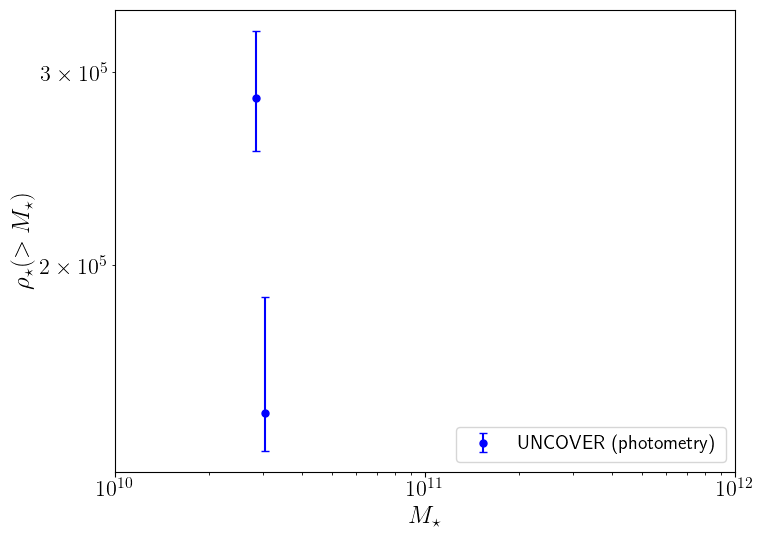

In [15]:
fig, ax = plt.subplots(1,1, figsize=(8,6))
ax.errorbar(Mstar_bins_mdl_phot[:idxhgM], rhostar_mdl_phot[:idxhgM], \
             #xerr = [Mstar_bins_mdl - Mstar_bins_lo, Mstar_bins_hi - Mstar_bins_mdl], \
             yerr = [rhostar_mdl_phot[:idxhgM] - rhostar_lo_phot[:idxhgM], rhostar_hi_phot[:idxhgM] - rhostar_mdl_phot[:idxhgM]],\
             fmt='o', capsize=3, elinewidth=1.5, color='b', ms=5, label=r'UNCOVER (photometry)')
ax.legend(fontsize=14, loc='lower right')
ax.set_xlim(1e10, 1e12)
#ax.set_ylim(*my_ylims)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$M_{\star}$', fontsize=18)
ax.set_ylabel(r'$\rho_{\star}(>M_{\star})$', fontsize=18)
#plt.savefig(savedir + 'stellar_density_vs_UNCOVER(Photo)_%s_%2.1f_z_%2.1f.png'%(mode,zbin_lo, zbin_hi), bbox_inches='tight')
plt.show()